<a href="https://colab.research.google.com/github/sarahselama/CSCI323-project/blob/main/Preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For datetime
from datetime import datetime

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")


# **Load the datasets**

In [31]:
sales = pd.read_csv("Sales_Dataset.csv", encoding='latin1')
production_recipe = pd.read_csv("production_recipe.csv", encoding='latin1')

# **Fix column names**

In [32]:
# Remove whitespace and normalize column names to snake_case
#SALES
sales.columns = (
    sales.columns
    .str.strip()
    .str.replace(' ', '_')
    .str.lower()
)

# PRODUCTION
production_recipe.columns = (
    production_recipe.columns
    .str.strip()
    .str.replace(' ', '_')
    .str.lower()
)

# Drop columns and fix typo after normalization
# Sales: drop --> every column except [System Date, Food ID, KSOP Receipe Name, Food Name, Quantity, Total Price, Food Cost]
# fix typo - now use the normalized name
sales.rename(columns={'ksop_reciepe_name': 'recipe'}, inplace=True)

sales = sales[
    [
        "system_date",
        "food_id",
        "recipe",
        "food_name",
        "quantity",
        "total_price",
        "food_cost"
    ]
]
# Production
# fix typo
production_recipe.rename(columns={'ingredians': 'ingredients'}, inplace=True)
production_recipe.rename(columns={'production_food_name': 'food_name'}, inplace=True)
# Convert date columns
sales['system_date'] = pd.to_datetime(sales['system_date'])

In [33]:
# Margin metrics (only if these columns exist)
if {'total_price', 'food_cost'}.issubset(sales.columns):
  #clean columns
    sales['total_price'] = sales['total_price'].astype(str).str.replace('$', '', regex=False).str.strip()
    sales['food_cost'] = sales['food_cost'].astype(str).str.replace('$', '', regex=False).str.strip()
  #convert columns to numeric values
    sales['total_price'] = pd.to_numeric(sales['total_price'], errors='coerce')
    sales['food_cost'] = pd.to_numeric(sales['food_cost'], errors='coerce')
  #add calculation
    sales['gross_margin'] = sales['total_price'] - sales['food_cost']
    sales['gross_margin_percent'] = (sales['gross_margin'] / sales['total_price']) * 100

print(sales.head())
print(production_recipe.head())

  system_date  food_id       recipe                                food_name  \
0  2024-02-07      893  Food Name 1                       Strawberry Sunrise   
1  2024-02-13      893  Food Name 1                       Strawberry Sunrise   
2  2024-02-04      893  Food Name 1                       Strawberry Sunrise   
3  2024-11-04     1010  Food Name 2  Pimento Cheese-Stuffed Jalapeno Poppers   
4  2024-02-13      919  Food Name 3                          Spice Whirlwind   

   quantity  total_price  food_cost  gross_margin  gross_margin_percent  
0         2         6.43       4.26          2.17             33.748056  
1         1        10.68       4.26          6.42             60.112360  
2         1         7.43       4.26          3.17             42.664872  
3         4         7.43       4.26          3.17             42.664872  
4         5         7.28       4.26          3.02             41.483516  
                food_name ingredients  quantity
0  Production Food Name 1  

# **Create array for ingredients and quantity**

In [14]:
# import re
# # 1. rename for consistency
# production_recipe = production_recipe.rename(
#     columns={"production_food_name":"food_name"}
# )

# # 2. build arrays

# #PRODUCTION RECIPE
# production_recipe_arrays = (
#     production_recipe
#       .groupby("food_name", sort = False)[["ingredients","quantity"]]
#       .apply(lambda grp: list(zip(grp.ingredients, grp.quantity)))
#       .reset_index(name="recipe")
# )

# print("\nProduction recipes:")
# display(production_recipe_arrays.head(20))



Production recipes:


,food_name,recipe
0,Production Food Name 1,"[(RM Name 1, 120.0), (RM Name 2, 12.5), (RM Na..."
1,Production Food Name 2,"[(RM Name 5, 50.0), (RM Name 8, 50.0), (RM Nam..."
2,Production Food Name 3,"[(RM Name 10, 3780.0), (RM Name 11, 100.0)]"
3,Production Food Name 4,"[(RM Name 10, 1000.0), (RM Name 12, 250.0), (R..."
4,Production Food Name 5,"[(RM Name 2, 0.43), (RM Name 18, 4.25), (RM Na..."
5,Production Food Name 6,"[(RM Name 22, 1111.0), (RM Name 23, 40.0)]"
6,Production Food Name 7,"[(RM Name 24, 110.0), (RM Name 5, 0.29), (RM N..."
7,Production Food Name 8,"[(RM Name 19, 500.0), (RM Name 10, 3780.0), (R..."
8,Production Food Name 9,"[(RM Name 22, 1000.0), (RM Name 19, 50.0), (RM..."
9,Production Food Name 10,"[(RM Name 30, 1000.0), (RM Name 19, 50.0), (RM..."


# **Sales data summary**

In [34]:
print("Descriptive Statistics for Sales:")
print("\nTop 15 Dishes Sold:")
top_dishes = sales.groupby(['food_id', 'food_name'])['quantity'].sum().sort_values(ascending=False).head(15)
print(top_dishes)

print("\nSales Columns")
print(sales.columns)
print("\nProduction Columns")
print(production_recipe.columns)

Descriptive Statistics for Sales:

Top 15 Dishes Sold:
food_id  food_name                             
893      Strawberry Sunrise                        5965
1002     Creole Shrimp and Grits                   5046
894      Crispy Karma                              4919
1319     Southern Fried Catfish Po' Boy            4698
939      The Crispy Crunch Burger                  4319
1008     Sweet Tea-Brined Pork Chops               4243
963      The Philly Cheesesteak Inspired Burger    3706
1000     Peach Perfection                          3431
931      Delish Dhaba                              3200
1381     Cajun Jambalaya                           2554
910      Curry Chronicles                          2372
940      Saffron Symphony                          2323
946      The Spicy Sriracha Kick Burger            2280
930      Epic Flavor Quest                         2179
1311     Banana Pudding                            2163
Name: quantity, dtype: int64

Sales Columns
Index(['syste

# **Merge sale data with production recipe to get ingredient demand per sale**

In [39]:
# Step 1: Merge sales with production_recipe to get ingredient-level demand per sale
# extract the numeric code of each Food Name
sales['Food Code'] = sales['recipe'].str.extract(r'(\d+)$').astype(int)
production_recipe['Food Code'] = production_recipe['food_name'].str.extract(r'(\d+)$').astype(int)

merged = pd.merge(
    sales,
    production_recipe,
    on="Food Code",
    how="inner",
    suffixes=("_sale", "_production")
)
# Step 2: Calculate total ingredient demand per sale row
# Each sale row now has a 'quantity' (dishes sold) and a 'quantity_y' (ingredient amount per dish)
merged['ingredient_total_qty'] = merged['quantity_sale'] * merged['quantity_production']
# Step 3: Aggregate total demand for each ingredient
ingredient_demand = (
    merged
    .groupby('ingredients')['ingredient_total_qty']
    .sum()
    .reset_index(name='total_demand')
    .sort_values('total_demand',ascending=False)
)

# Step 4: Display the result
print(ingredient_demand.head(10))


#check in order of RM Name
ingredient_demand['RM Code'] = (
    ingredient_demand['ingredients']
    .str.extract(r'(\d+)$')
    .astype(int)
)
ingredient_demand_sorted = ingredient_demand.sort_values('RM Code')
print(ingredient_demand_sorted.head(10))

    ingredients  total_demand
74   RM Name 55   65695942.92
112   RM Name 9   32469605.79
59   RM Name 41   31843050.00
122  RM Name 99   28458000.00
23   RM Name 12   25027710.00
63   RM Name 45   24513821.69
1    RM Name 10   21283690.00
79    RM Name 6   16480574.00
90    RM Name 7   11046729.18
34   RM Name 19    7388593.18
    ingredients  total_demand  RM Code
0     RM Name 1     779040.00        1
35    RM Name 2    1228765.10        2
46    RM Name 3      19316.00        3
57    RM Name 4      19316.00        4
68    RM Name 5    2398083.47        5
79    RM Name 6   16480574.00        6
90    RM Name 7   11046729.18        7
101   RM Name 8    6918264.53        8
112   RM Name 9   32469605.79        9
1    RM Name 10   21283690.00       10


# **Get daily ingredient demand**

In [42]:
restaurant_daily_ingredient_demand = (
    merged
    .groupby([
        pd.Grouper(key='system_date', freq='D'),
        'ingredients',
        ])['ingredient_total_qty']
    .sum()
    .reset_index()
)

restaurant_daily_ingredient_demand.head()

,system_date,ingredients,ingredient_total_qty
0,2024-01-01,RM Name 1,480.0
1,2024-01-01,RM Name 10,48540.0
2,2024-01-01,RM Name 100,500.0
3,2024-01-01,RM Name 102,5000.0
4,2024-01-01,RM Name 103,300.0


In [ ]:
# Example: Apply a 5% wastage rate to all ingredient demand
wastage_rate = 0.05
daily_ingredient_demand['ingredient_total_qty_adj'] = daily_ingredient_demand['ingredient_total_qty'] * (1 + wastage_rate)

# Summarize the impact of wastage adjustment by ingredient type
adj_summary = daily_ingredient_demand.groupby('ingredient_type')['ingredient_total_qty_adj'].sum().reset_index()
print("Total Adjusted Ingredient Demand by Type (with 5% wastage):")
print(adj_summary)

Total Adjusted Ingredient Demand by Type (with 5% wastage):
   ingredient_type  ingredient_total_qty_adj
0            Other              0.000000e+00
1  Production Food              5.047642e+06
2     Raw Material              1.418314e+07


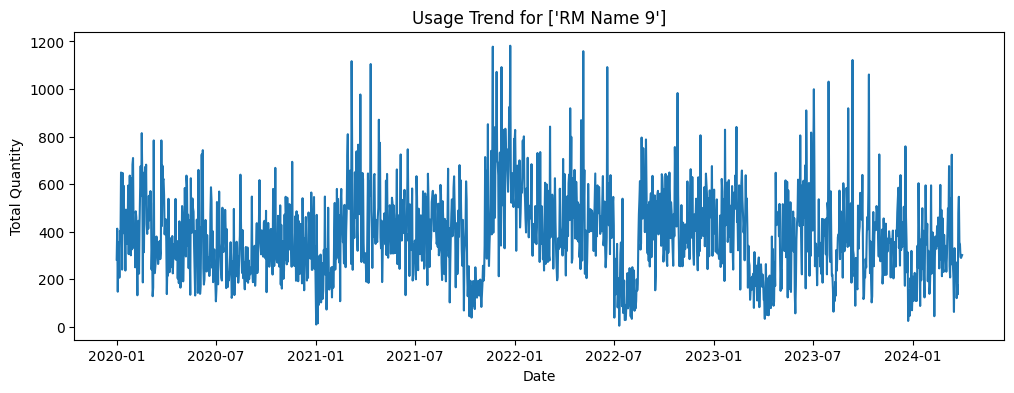

In [ ]:
### **Stage 4: Exploratory Analysis**

#### 1. Ingredient Usage Trends (Time Series Plot)

# Plot total ingredient demand over time for a selected ingredient
ingredient_name = "['RM Name 9']"
trend = daily_ingredient_demand[daily_ingredient_demand['ingredients'] == ingredient_name]
plt.figure(figsize=(12, 4))
plt.plot(trend['system_date'], trend['ingredient_total_qty'])
plt.title(f"Usage Trend for {ingredient_name}")
plt.xlabel("Date")
plt.ylabel("Total Quantity")
plt.show()

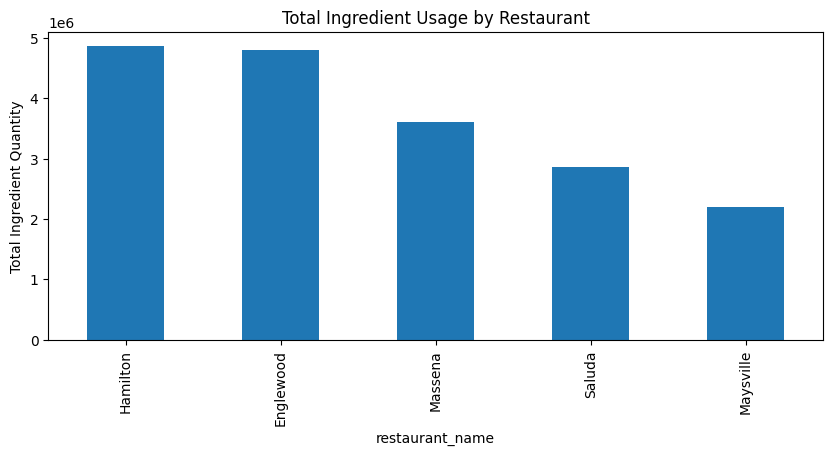

In [ ]:
#### 2. Restaurant Comparison (Bar Plot)
# Compare total ingredient usage by restaurant
comp = restaurant_daily_ingredient_demand.groupby('restaurant_name')['ingredient_total_qty'].sum().sort_values(ascending=False)
comp.plot(kind='bar', figsize=(10, 4), title='Total Ingredient Usage by Restaurant')
plt.ylabel("Total Ingredient Quantity")
plt.show()

In [ ]:
#### 3. Dish-Ingredient Mapping
# Map which dishes use a specific ingredient
ingredient_name = "['RM Name 9']"
dishes_with_ingredient = food_recipe[food_recipe['ingredients'].apply(lambda x: ingredient_name in str(x))]
print(dishes_with_ingredient[['food_name', 'ingredients']])

                                            food_name  ingredients
77                  The Cheesy Jalape¤o Popper Burger  [RM Name 9]
94                     The Pesto Basil Chicken Burger  [RM Name 9]
104              The Dynamic Duo Surf and Turf Burger  [RM Name 9]
119                                  Grand Gastronomy  [RM Name 9]
177                             Honey Ginger Lemonade  [RM Name 9]
190              The Sweet Heat Mango Habanero Burger  [RM Name 9]
218                                   Flaming Flavors  [RM Name 9]
228                                    Banana Pudding  [RM Name 9]
249              Southern Comfort Chicken and Waffles  [RM Name 9]
270                 The Zesty Guacamole Fiesta Burger  [RM Name 9]
293                       The Southwest Fiesta Burger  [RM Name 9]
313                                   Mojito Mocktail  [RM Name 9]
361                                      Delish Dhaba  [RM Name 9]
387               The Tangy Teriyaki Pineapple Burger  [RM Nam

In [ ]:
# 4. Cost Analysis
# Calculate cost contribution of each ingredient (if cost per ingredient is available)

# Example cost mapping (replace with your actual data)
cost_mapping = pd.DataFrame({
    'ingredients': ["['RM Name 9']", "['RM Name 44']"],
    'unit_cost': [0.25, 0.10]
})

# Merge with daily ingredient demand
cost_analysis = pd.merge(
    daily_ingredient_demand,
    cost_mapping,
    on='ingredients',
    how='left'
)

# Calculate total cost (using wastage-adjusted quantity)
cost_analysis['total_cost'] = cost_analysis['ingredient_total_qty_adj'] * cost_analysis['unit_cost']

# Example: total cost per ingredient
total_cost_per_ingredient = cost_analysis.groupby('ingredients')['total_cost'].sum().reset_index()

# Print total cost per ingredient in descending order
print(total_cost_per_ingredient.sort_values('total_cost', ascending=False))


                      ingredients  total_cost
208                 ['RM Name 9']  158367.300
183                ['RM Name 44']   24437.175
2     ['Production Food Name 19']       0.000
1     ['Production Food Name 18']       0.000
0    ['Production Food Name 102']       0.000
..                            ...         ...
207                ['RM Name 89']       0.000
209                ['RM Name 90']       0.000
210                ['RM Name 91']       0.000
211                ['RM Name 94']       0.000
212                           nan       0.000

[213 rows x 2 columns]


In [ ]:
#### 5. Outlier Detection

# Identify days with unusually high ingredient usage (e.g., z-score > 3)
from scipy.stats import zscore
daily_ingredient_demand['zscore'] = daily_ingredient_demand.groupby('ingredients')['ingredient_total_qty'].transform(zscore)
outliers = daily_ingredient_demand[daily_ingredient_demand['zscore'].abs() > 3]
print(outliers[['system_date', 'ingredients', 'ingredient_total_qty', 'zscore']])

       system_date      ingredients  ingredient_total_qty    zscore
46      2020-01-01  ['RM Name 159']                 8.000  3.347332
288     2020-01-03  ['RM Name 137']                 0.005  3.662198
367     2020-01-03  ['RM Name 290']                10.000  3.737443
753     2020-01-06  ['RM Name 225']                12.000  8.678665
763     2020-01-06  ['RM Name 249']                 6.000  3.242901
...            ...              ...                   ...       ...
192952  2024-03-29  ['RM Name 215']                16.000  3.286547
193101  2024-03-30  ['RM Name 259']                 4.000  3.205073
193164  2024-03-31  ['RM Name 135']                15.000  3.083537
193165  2024-03-31  ['RM Name 136']                13.000  3.173414
193181  2024-03-31  ['RM Name 168']                13.000  3.173414

[2663 rows x 4 columns]


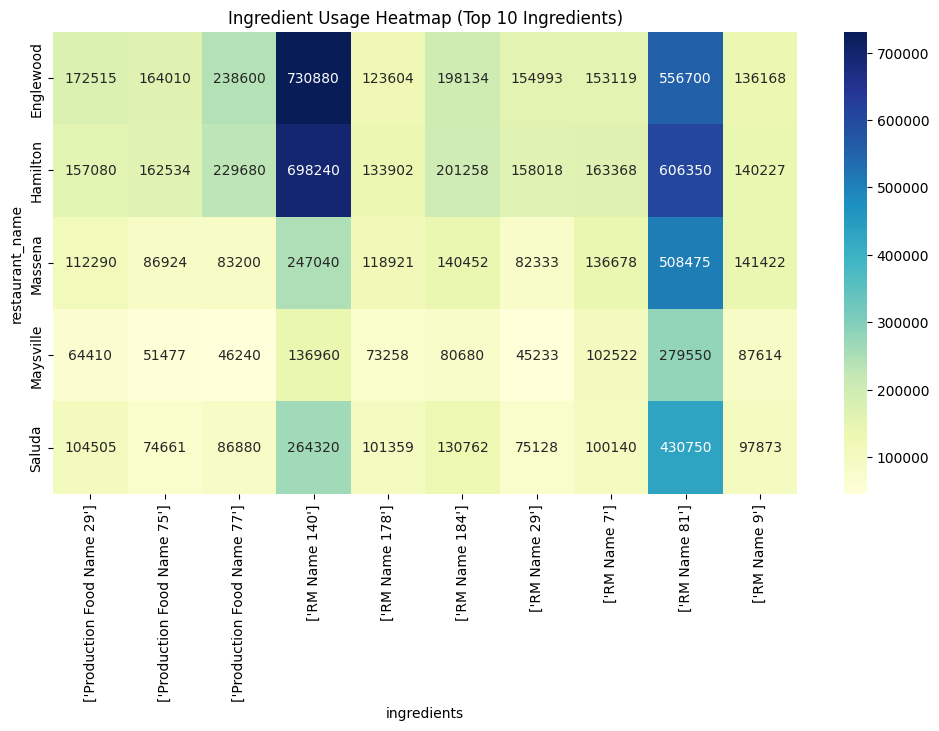

In [ ]:
#### 7. Visualization (Heatmap Example)
# Heatmap of ingredient usage by restaurant and ingredient (top 10 ingredients)
top_ingredients = ingredient_demand.sort_values('total_demand', ascending=False).head(10)['ingredient']
heatmap_data = restaurant_daily_ingredient_demand[
    restaurant_daily_ingredient_demand['ingredients'].isin(top_ingredients)
].pivot_table(
    index='restaurant_name',
    columns='ingredients',
    values='ingredient_total_qty',
    aggfunc='sum',
    fill_value=0
)
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Ingredient Usage Heatmap (Top 10 Ingredients)")
plt.show()

In [ ]:
# According to the workflow summary in the notebook, the next step after exploratory analysis is:
# Stage 5: Forecasting Preparation and Stage 6: Forecasting Ingredient Needs

print("Next Steps:")
print("""
1. Forecasting Preparation:
    - Use the 'restaurant_daily_ingredient_demand' DataFrame as the historical dataset.
    - Structure the data for time series forecasting (e.g., set date as index, handle missing dates).

2. Forecasting Ingredient Needs:
    - For each restaurant and ingredient, fit a time series forecasting model (e.g., ARIMA, Prophet, Exponential Smoothing).
    - Predict future ingredient demand per restaurant.
    - Store forecasts in a new DataFrame or table for inventory planning.

3. (Optional) Design and implement the normalized tables for a restaurant management system as described earlier.
""")

In [ ]:
#### 6. Correlation Analysis
# Correlation between ingredient demand and sales channel/order type
merged = pd.merge(
    sales_ingredients,
    sales[['system_date', 'sales_channel', 'order_type', 'restaurant_name']],
    on=['system_date', 'restaurant_name'],
    how='left'
)
corr = pd.pivot_table(
    merged,
    values='ingredient_total_qty',
    index='sales_channel',
    columns='order_type',
    aggfunc='sum'
)
print(corr)
'''

In [ ]:
#### 7. Visualization (Heatmap Example)
# Heatmap of ingredient usage by restaurant and ingredient (top 10 ingredients)
top_ingredients = ingredient_demand.sort_values('total_demand', ascending=False).head(10)['ingredient']
heatmap_data = restaurant_daily_ingredient_demand[
    restaurant_daily_ingredient_demand['ingredients'].isin(top_ingredients)
].pivot_table(
    index='restaurant_name',
    columns='ingredients',
    values='ingredient_total_qty',
    aggfunc='sum',
    fill_value=0
)
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Ingredient Usage Heatmap (Top 10 Ingredients)")
plt.show()

In [ ]:
# Stage 5: Forecasting Preparation and Stage 6: Forecasting Ingredient Needs

**Forecasting Preparation Steps:**

1. **Select the DataFrame:**
    Use the `restaurant_daily_ingredient_demand` DataFrame as your historical dataset for forecasting.

2. **Data Structuring:**
    - Ensure `system_date` is a datetime type and sorted.
'''

The code forecasts **30 days** into the future for each restaurant and ingredient combination. This is done by splitting the time series into a training set (`train = ts.iloc[:-30]`) and a test set (`test = ts.iloc[-30:]`), then generating forecasts for the length of the test set, which is 30 days.aurant and ingredient combination. This is done by splitting the time series into a training set (`train = ts.iloc[:-30]`) and a test set (`test = ts.iloc[-30:]`), then generating forecasts for the length of the test set, which is 30 days.


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
import joblib

import os

forecast_results = []

# Create a folder to store models if it doesn't exist
model_dir = "models"
os.makedirs(model_dir, exist_ok=True)

restaurants = restaurant_daily_ingredient_demand['restaurant_name'].unique()
ingredients = restaurant_daily_ingredient_demand['ingredients'].unique()

print(f"Total restaurants: {len(restaurants)}")
print(f"Total ingredients: {len(ingredients)}")

for r_idx, restaurant in enumerate(restaurants, 1):
    print(f"\nProcessing restaurant {r_idx}/{len(restaurants)}: {restaurant}")
    for i_idx, ingredient in enumerate(ingredients, 1):
        print(f"  Ingredient {i_idx}/{len(ingredients)}: {ingredient}", end=' ... ')
        ts = restaurant_daily_ingredient_demand[
            (restaurant_daily_ingredient_demand['restaurant_name'] == restaurant) &
            (restaurant_daily_ingredient_demand['ingredients'] == ingredient)
        ][['system_date', 'ingredient_total_qty']].copy()

        if ts.empty or ts['ingredient_total_qty'].sum() == 0:
            print("skipped (no data)")
            continue

        ts = ts.set_index('system_date').sort_index()
        all_dates = pd.date_range(ts.index.min(), ts.index.max(), freq='D')
        ts = ts.reindex(all_dates, fill_value=0)
        ts.index.name = 'system_date'

        ts['lag_1'] = ts['ingredient_total_qty'].shift(1)
        ts['rolling_mean_7'] = ts['ingredient_total_qty'].rolling(window=7).mean()
        ts['day_of_week'] = ts.index.dayofweek
        ts = ts.fillna(0)

        train = ts.iloc[:-30]
        test = ts.iloc[-30:]

        # Exponential Smoothing Forecast
        try:
            model = ExponentialSmoothing(train['ingredient_total_qty'], trend='add', seasonal=None)
            fit = model.fit()
            fit.save(os.path.join(model_dir, f"es_{restaurant}_{ingredient}.pkl"))
            forecast_es = fit.forecast(steps=len(test))
            print("ES", end=' ')
        except Exception as e:
            forecast_es = [None] * len(test)
            print("ES[fail]", end=' ')

        X_train = train[['lag_1', 'rolling_mean_7', 'day_of_week']]
        y_train = train['ingredient_total_qty']
        X_test = test[['lag_1', 'rolling_mean_7', 'day_of_week']]

        # MLPRegressor Forecast
        try:
            mlp = MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
            mlp.fit(X_train, y_train)
            joblib.dump(mlp, os.path.join(model_dir, f"mlp_{restaurant}_{ingredient}.joblib"))
            forecast_mlp = mlp.predict(X_test)
            print("MLP", end=' ')
        except Exception as e:
            forecast_mlp = [None] * len(test)
            print("MLP[fail]", end=' ')

        # RandomForestRegressor Forecast
        try:
            rf = RandomForestRegressor(n_estimators=100, random_state=42)
            rf.fit(X_train, y_train)
            joblib.dump(rf, os.path.join(model_dir, f"rf_{restaurant}_{ingredient}.joblib"))
            forecast_rf = rf.predict(X_test)
            print("RF", end=' ')
        except Exception as e:
            forecast_rf = [None] * len(test)
            print("RF[fail]", end=' ')

        # Ridge Regression Forecast
        try:
            ridge = Ridge()
            ridge.fit(X_train, y_train)
            joblib.dump(ridge, os.path.join(model_dir, f"ridge_{restaurant}_{ingredient}.joblib"))
            forecast_ridge = ridge.predict(X_test)
            print("Ridge", end=' ')
        except Exception as e:
            forecast_ridge = [None] * len(test)
            print("Ridge[fail]", end=' ')

        print("done")

        for i, date in enumerate(test.index):
            forecast_results.append({
                'restaurant_name': restaurant,
                'ingredient': ingredient,
                'date': date,
                'actual': test['ingredient_total_qty'].iloc[i],
                'forecast_es': forecast_es[i] if forecast_es is not None else None,
                'forecast_mlp': forecast_mlp[i] if forecast_mlp is not None else None,
                'forecast_rf': forecast_rf[i] if forecast_rf is not None else None,
                'forecast_ridge': forecast_ridge[i] if forecast_ridge is not None else None
            })

print("\nAll forecasts complete. Saving results...")
forecast_df = pd.DataFrame(forecast_results)
forecast_df.to_parquet('forecast_results.parquet', index=False)
print("Results saved to 'forecast_results.parquet'")
